In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from torch.utils.data import TensorDataset, DataLoader

import kagglehub

import time
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

c:\Users\Mike\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cuda


In [3]:
#adjustable parameters

from Classifiers import NaiveClassifier

num_epochs   = 1
lr           = 3e-4 #same lr for both to reduce confounding variables
batch_size   = 256
num_classes  = 8    
weight_decay = 1e-4 #to reduce overfitting

criterion = nn.CrossEntropyLoss()

naive_classifier = NaiveClassifier(num_classes).to(device)


naive_optimizer = optim.Adam(naive_classifier.parameters(), lr=lr, weight_decay=weight_decay)

In [19]:
#importing images
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

#one pathology per image / equal number of images per pathology
full_dataset = kagglehub.dataset_download("obulisainaren/retinal-oct-c8")
full_dataset += '/RetinalOCT_Dataset/RetinalOCT_Dataset' 
train_dataset = ImageFolder(
    root=full_dataset+'/train',
    transform=transform
)

train_loader = DataLoader(
   dataset=train_dataset,
   batch_size=batch_size,
   shuffle=True,
   #increases compute speed
   num_workers=8,
   pin_memory=True
)

val_dataset = ImageFolder(
    root= full_dataset+'/val',
    transform=transform
)

#val
val_loader = DataLoader(
   dataset=val_dataset,
   batch_size=batch_size,
   shuffle=False,
   #increases compute speed
   num_workers=8,
   pin_memory=True
)

#test
test_dataset = ImageFolder(
    root= full_dataset+'/test',
    transform=transform
)

test_loader = DataLoader(
   dataset=test_dataset,
   batch_size=batch_size,
   shuffle=False,
   #increases compute speed
   num_workers=8,
   pin_memory=True
)

In [8]:
#training naive - classifier: 2 linear layers
start_time = time.perf_counter()

naive_train_losses = []
naive_val_losses = []

for epoch in range(num_epochs):
    naive_classifier.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        output = naive_classifier(images)
        loss = criterion(output, labels)

        naive_optimizer.zero_grad()
        loss.backward()
        naive_optimizer.step()

        total_loss += loss.item()

        predicted = output.argmax(dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_train_loss = total_loss / len(train_loader)
    accuracy = 100 * correct / total
    end_time = time.perf_counter()
    naive_train_losses.append(epoch_train_loss)

    #val
    naive_classifier.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            
            output = naive_classifier(images)
            loss = criterion(output, labels)
            
            val_loss += loss.item()

            predicted = output.argmax(dim=1)

            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    epoch_val_loss = val_loss / len(val_loader)
    epoch_val_accuracy = 100 * val_correct / val_total
    naive_val_losses.append(epoch_val_loss)


    print(
        f"Epoch {epoch+1}: "
        f"Training: Loss={epoch_train_loss:.4f}, "
        f"Accuracy={accuracy:.2f}%      "
        f"Validation: Loss={epoch_val_loss:.4f}, "
        f"Val Acc={epoch_val_accuracy:.2f}%"
    )
    


naive_accuracy = epoch_val_accuracy
naive_train_time = end_time - start_time

print(
    f"Results: Accuracy={naive_accuracy:.2f}% "
    f"Training Duration={naive_train_time:.6f} sec"
)

Epoch 1: Training: Loss=2.1119, Accuracy=18.07%      Validation: Loss=1.8815, Val Acc=20.64%
Results: Accuracy=20.64% Training Duration=44.854894 sec


In [ ]:
#torch.save(naive_classifier.state_dict(), "naive_classifier.pth")

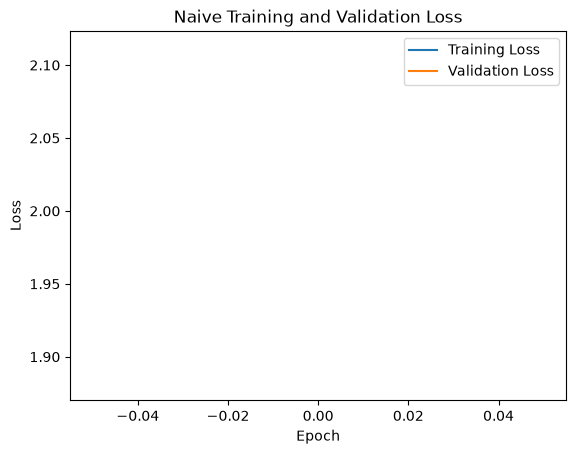

In [ ]:
plt.plot(naive_train_losses, label="Training Loss")
plt.plot(naive_val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Naive Training and Validation Loss")
plt.legend()
plt.show()

In [13]:
#test - naive
test_naive_classifier = NaiveClassifier(8).to(device)
test_naive_classifier.load_state_dict(torch.load("models/naive_classifier.pth", map_location=device))
test_naive_classifier.eval()

naive_correct = 0
top2_correct = 0
total = 0
conf_right, conf_wrong = 0.0, 0.0
n_wrong = 0
naive_class_correct = {c: 0 for c in range(num_classes)}
class_total = {c: 0 for c in range(num_classes)}

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        #raw image straight to the classifier - no encoder in this arm
        logits = test_naive_classifier(images)

        #raw scores -> probabilities that sum to 1
        probs = torch.softmax(logits, dim=1)
        conf, naive_predict = probs.max(dim=1)

        #was the right answer in the top 2 guesses
        top2 = probs.topk(2, dim=1).indices
        top2_correct += (top2 == labels.unsqueeze(1)).any(dim=1).sum().item()

        #margin: how far ahead the winner is, instead of how much mass it holds
        conf = probs.topk(2, dim=1).values.diff(dim=1).abs().squeeze(1)

        #which predictions were right
        hit = (naive_predict == labels)
        naive_correct += hit.sum().item()
        total += labels.size(0)

        #confidence split by right vs wrong
        conf_right += conf[hit].sum().item()
        conf_wrong += conf[~hit].sum().item()
        n_wrong += (~hit).sum().item()

        #tally each class separately
        for label, e_pred in zip(labels, naive_predict):
            l = label.item()
            class_total[l] += 1
            naive_class_correct[l] += int(l == e_pred.item())


print(f"Naive test accuracy:             {100 * naive_correct / total:.2f}%")
print(f"Top-2 accuracy:                  {100 * top2_correct / total:.2f}%")
print(f"Confidence when right:           {100 * conf_right / naive_correct:.2f}%")
print(f"Confidence when wrong:           {100 * conf_wrong / n_wrong:.2f}%")
print()
print(f"{'Class':<10} {'Naive':>10}")
for c in range(num_classes):
    name = test_dataset.classes[c]
    e_acc = 100 * naive_class_correct[c] / class_total[c]
    print(f"{name:<10} {e_acc:>9.2f}%")

Naive test accuracy:             50.50%
Top-2 accuracy:                  74.14%
Confidence when right:           36.03%
Confidence when wrong:           9.82%

Class           Naive
AMD            99.43%
CNV            37.43%
CSR            61.14%
DME            26.00%
DR             27.43%
DRUSEN         28.29%
MH             66.57%
NORMAL         57.71%


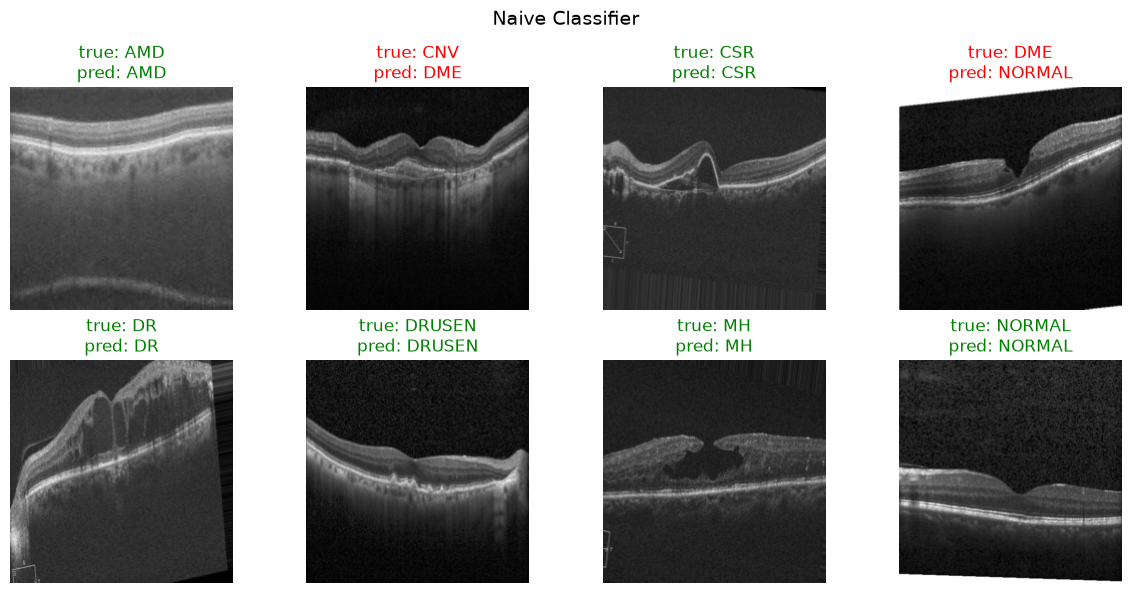

In [20]:
#visualizing results
found = {}
for images, labels in test_loader:
    for img, lab in zip(images, labels):
        c = lab.item()
        if c not in found:
            found[c] = img
    if len(found) == 8:
        break

true_ids = sorted(found)
batch = torch.stack([found[c] for c in true_ids])

test_naive_classifier.eval()
with torch.no_grad():
    pred_ids = test_naive_classifier(batch.to(device)).argmax(dim=1).cpu().tolist()

class_names = test_loader.dataset.classes

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle("Naive Classifier", fontsize=14)

for ax, t, p in zip(axes.flat, true_ids, pred_ids):
    ax.imshow((found[t].squeeze() + 1) / 2, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f"true: {class_names[t]}\npred: {class_names[p]}",
                 color='green' if t == p else 'red')
    ax.axis('off')

plt.tight_layout()
plt.savefig("result_images/frozen_naive_results.png", dpi=300, bbox_inches='tight')
plt.show()